In [1]:
import pickle
from torch.utils.data import Subset
from torch_geometric.datasets import BA2MotifDataset
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv,global_add_pool
from torch_geometric.loader import DataLoader
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import random_split
import matplotlib.pyplot as plt


c:\Users\mahboub\miniforge3\envs\GNN\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\mahboub\miniforge3\envs\GNN\Lib\site-packages\torch_scatter\_version_cpu.pyd
  import torch_geometric.typing
c:\Users\mahboub\miniforge3\envs\GNN\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\mahboub\miniforge3\envs\GNN\Lib\site-packages\torch_cluster\_version_cpu.pyd
  import torch_geometric.typing
c:\Users\mahboub\miniforge3\envs\GNN\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\mahboub\miniforge3\envs\GNN\Lib\site-packages\torch_spline_conv\_version_cpu.pyd
  import torch_geometric.typing
c:

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
dataset=BA2MotifDataset(root='./data/BA2Motif')
with open("./data/splits.pkl", "rb") as f:
    splits=pickle.load(f)

train_dataset=Subset(dataset,splits["train"])
val_dataset=Subset(dataset,splits["val"])


In [4]:
class GINGraphClf(nn.Module):
    def __init__(self, in_dim,out_dim, hidden_dim=64):
        super().__init__()
        self.conv1=GINConv(nn.Sequential(nn.Linear(in_dim, hidden_dim), nn.ReLU(),nn.BatchNorm1d(hidden_dim), nn.Linear(hidden_dim, hidden_dim),nn.ReLU()))
        self.conv2=GINConv(nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),nn.BatchNorm1d(hidden_dim), nn.Linear(hidden_dim, hidden_dim),nn.ReLU()))
        self.conv3=GINConv(nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),nn.BatchNorm1d(hidden_dim), nn.Linear(hidden_dim, hidden_dim),nn.ReLU()))
        
        self.mlp = nn.Sequential(
            nn.Linear(3*hidden_dim, hidden_dim//2),
            nn.Dropout(0.5),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, out_dim),
            nn.Sigmoid()
        )
    
    def forward(self, x, edge_index, batch):
        h1=self.conv1(x, edge_index)
        h2=self.conv2(h1, edge_index)
        h3=self.conv3(h2, edge_index)

        h1=global_add_pool(h1,batch)
        h2=global_add_pool(h2,batch)
        h3=global_add_pool(h3,batch)    


        x=torch.cat([h1,h2,h3],dim=1)


        return self.mlp(x)

In [5]:
config={
    'hidden_dim':64,
    'learning_rate':0.001,
    'weight_decay':0.001,
    'epochs':100,
    'batch_size':32,
    'patience':20           # early stopping
}

In [6]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [7]:
train_loader=DataLoader(train_dataset,batch_size=config['batch_size'],shuffle=True)
validation_loader=DataLoader(val_dataset,batch_size=config['batch_size'],shuffle=False)

In [8]:
model=GINGraphClf(dataset.num_node_features,dataset.num_classes).to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=config['learning_rate'],weight_decay=config['weight_decay'])
criterion=nn.CrossEntropyLoss()

In [9]:
def trian_one_epoch(model,loader,optimizer,criterion,device):
    model.train()
    total_loss=0
    for data in loader:
        data=data.to(device)
        optimizer.zero_grad()
        output=model(data.x,data.edge_index,data.batch)
        loss=criterion(output,data.y)
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()*data.num_graphs
    return total_loss/len(loader.dataset)

def evaluate(model , loader,device):
    model.eval()
    correct=0
    total=0
    with torch.no_grad():
        for data in loader:
            data=data.to(device)
            output=model(data.x,data.edge_index,data.batch)
            pred=output.argmax(dim=1)
            correct+=(pred==data.y).sum().item()
            total+=len(data.y)
    return correct/total

In [10]:
best_val_acc=0.0
patience_counter=0
best_model_state=None

train_losses = []
val_accs = []


with tqdm(total=config["epochs"],desc="Training epochs",unit="epoch") as pbar_epoch:
    for epoch in range(config["epochs"]):
        train_loss=trian_one_epoch(model,train_loader,optimizer,criterion,device)
        val_acc=evaluate(model,validation_loader,device)
        train_losses.append(train_loss)
        val_accs.append(val_acc)
        pbar_epoch.set_postfix({"train_loss":train_loss,"val_acc":val_acc})
        pbar_epoch.update(1)
        if val_acc>best_val_acc:
            best_val_acc=val_acc
            patience_counter=0
            best_model_state=model.state_dict().copy()
        else:
            patience_counter+=1
            if patience_counter>=config["patience"]:
                tqdm.write(f"Early stopping at epoch {epoch+1}")
                break

model.load_state_dict(best_model_state)
tqdm.write(f"Best validation accuracy: {best_val_acc:.4f}")

Training epochs:  23%|██▎       | 23/100 [00:08<00:27,  2.84epoch/s, train_loss=0.314, val_acc=1]   

Early stopping at epoch 23
Best validation accuracy: 1.0000


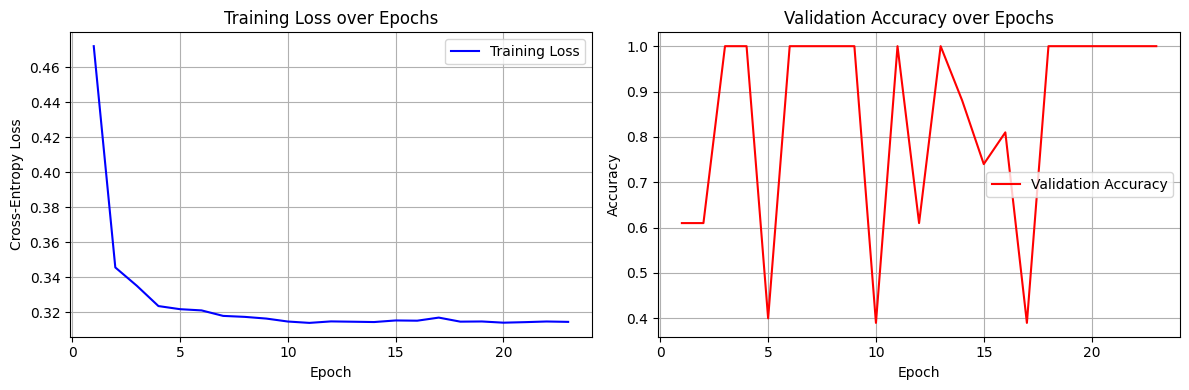

In [11]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, 'b-', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_accs, 'r-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy over Epochs')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
model.eval()
for param in model.parameters():
    param.requires_grad=False

torch.save({
    'model_state_dict':best_model_state,
    'config':config,
    'best_val_acc':best_val_acc,
},"./models/GIN/best_gin_model.pt"
)
tqdm.write(" Model frozen and saved as 'best_gin_model.pt'")

 Model frozen and saved as 'best_gin_model.pt'
